---
title: "Heat Equation"
format: 
    html: 
        toc: true
execute: 
  enabled: true
bibliography: "../../references.bib"
jupyter: python3
---

Here, we characterise the posterior distribution of the diffusion coefficient of a two-dimensional heat equation. We will consider a similar setup to that described in @Cui2022.

# Problem Setup

We consider the domain $\Omega := (0, 3) \times (0, 1)$, with boundary denoted by $\partial \Omega$. The change in temperature, $u(\boldsymbol{x}, t)$, at each point in the domain over time can be modelled by the heat equation,

$$
    \frac{\partial u(\boldsymbol{x}, t)}{\partial t} = \nabla \cdot (\kappa(\boldsymbol{x}) \nabla u(\boldsymbol{x}, t)) + f(\boldsymbol{x}, t), \quad \boldsymbol{x} \in \Omega, t \in (0, T],
$$

where $\kappa(\boldsymbol{x})$ denotes the (spatially varying) diffusion coefficient, and $f(\boldsymbol{x}, t)$ denotes the forcing term, which models heat sources or sinks. We set the end time to $T = 10$, and impose the initial and boundary conditions

$$
\begin{align*}
    u(\boldsymbol{x}, 0) &= 0, \qquad \boldsymbol{x} \in \Omega, \\
    (\kappa(\boldsymbol{x}) \nabla u(\boldsymbol{x}, t)) \cdot \boldsymbol{n} &= 0, \qquad \boldsymbol{x} \in \partial\Omega.
\end{align*}
$$

In the above, $\boldsymbol{n}$ denotes the outward-facing normal vector on the boundary of the domain.

We assume that the forcing term is given by

$$
    f(\boldsymbol{x}, t) = c \left(\exp\left(−\frac{1}{2r^{2}}||\boldsymbol{x} − \boldsymbol{a}||^{2}\right) − \exp\left(-\frac{1}{2r^{2}}||\boldsymbol{x} − \boldsymbol{b}||^{2}\right)\right),
$$

where $\boldsymbol{a} = \begin{bmatrix} 1/2, 1/2 \end{bmatrix}^{\top}$, $\boldsymbol{b} = [5/2, 1/2]^{\top}$, and $c = 5 \pi \times 10^{-2}$.

## Prior Density

We endow the logarithm of the unknown diffusion coefficient with a process convolution prior; that is,

$$
    \log(\kappa(\boldsymbol{x})) = \log(\bar{\kappa}(\boldsymbol{x})) + \sum_{i=1}^{d} \xi^{(i)} \exp\left(-\frac{1}{2r^{2}}\left\lVert\boldsymbol{x} - \boldsymbol{x}^{(i)}\right\rVert^{2}\right),
$$

where $d=27$, $\log(\bar{\kappa}(\boldsymbol{x}))=-5$, $r=1/16$, the coefficients $\{\xi^{(i)}\}_{i=1}^{d}$ are independent and follow the unit Gaussian distribution, and the centres of the kernel functions, $\{\boldsymbol{x}^{(i)}\}_{i=1}^{d}$, form a grid over the domain (see @fig-ktrue).

## Data

To estimate the diffusivity coefficient, we assume that we have access to measurements of the temperature at 13 locations in the model domain (see @fig-utrue), recorded at one-second intervals. This gives a total of 130 measurements. All measurements are corrupted by i.i.d. Gaussian noise with zero mean and a standard deviation of $\sigma=1.65 \times 10^{-2}$.

# Implementation in $\texttt{deep\_tensor}$

We will now use $\texttt{deep\_tensor}$ to construct a DIRT approximation to the posterior. To accelerate this process, we will use a reduced order model in place of the full model. Then, we will illustrate some debiasing techniques which use the DIRT approximation to the posterior, in combination with the full model, to accelerate the process of drawing exact posterior samples.

In [1]:
from matplotlib import pyplot as plt
import torch

import deep_tensor as dt
from examples.heat import setup_heat_problem, plot_dl_function
from examples.plotting import add_arrows, pairplot, set_plot_style

In [2]:
torch.manual_seed(1)
set_plot_style()

We begin by defining the prior, (full) model and reduced order model.

The full model is implemented in [FEniCS](https://fenicsproject.org/download/archive/), on a $96 \times 32$ grid, using piecwise linear basis functions. Timestepping is done using the backward Euler method. The reduced order model is constructed using the proper orthogonal decomposition [see, *e.g.*, @Benner2015].

In [3]:
#| output: false

# Construct the prior, full model and reduced order model
prior, model_full, model_rom = setup_heat_problem()

Next, we will generate the true log-diffusion coefficient using a sample from the prior. The true log-diffusion coefficient is plotted in @fig-ktrue.

In [4]:
xi_true = torch.randn(prior.dim)
logk_true = prior.transform(xi_true)

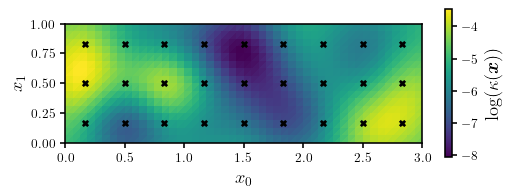

In [5]:
#| code-fold: true
#| fig-align: center
#| fig-cap: The true log-diffusion coefficient, $\log(\kappa(\boldsymbol{x}))$, and the centres of the kernel functions of the process convolution prior (black crosses).
#| label: fig-ktrue

fig, ax = plt.subplots(figsize=(6.0, 2.0))
cbar_label = r"$\log(\kappa(\bm{x}))$"
plot_dl_function(fig, ax, model_full.vec2func(logk_true), cbar_label)
ax.scatter(*prior.ss.T, s=16, c="k", marker="x")
ax.set_xlabel(r"$x_{0}$")
ax.set_ylabel(r"$x_{1}$")
plt.show()

Next, we will solve the (full) model to obtain the modelled temperatures corresponding to the true diffusion coefficient, and use these to generate some synthetic data. @fig-utrue shows the true temperature field at time $T=10$, as well as the observation locations.

In [6]:
# Generate true temperature field
u_true = model_full.solve(logk_true)

# Specify magnitude of observation noise
std_error = 1.65e-2
var_error = std_error ** 2

# Extract true temperatures at the observation locations and add 
# observation noise
d_obs = model_full.observe(u_true)
noise = std_error * torch.randn_like(d_obs)
d_obs += noise

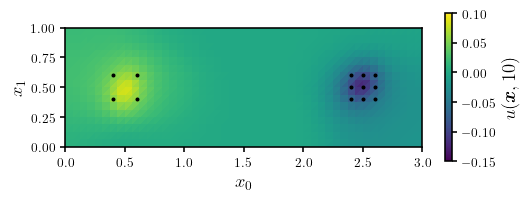

In [7]:
#| code-fold: true
#| fig-align: center
#| fig-cap: The true final temperature distribution, $u(\boldsymbol{x}, 10)$, and the observation locations (black dots).
#| label: fig-utrue

fig, ax = plt.subplots(figsize=(6.0, 2.0))
cbar_label = r"$u(\bm{x}, 10)$"
plot_dl_function(fig, ax, model_full.vec2func(u_true[:, -1]), cbar_label, vmin=-0.15, vmax=0.10)
ax.scatter(*model_full.xs_obs.T, s=16, c="k", marker=".")
ax.set_xlabel(r"$x_{0}$")
ax.set_ylabel(r"$x_{1}$")
plt.show()

## Building the DIRT Object

Now we will build a DIRT object to approximate the posterior density of the coefficients, $\{\xi^{(i)}\}_{i=1}^{d}$, used to parametrise the log-diffusion coefficient, for the reduced-order model. We begin by defining functions which return the potential associated with the likelihood and prior.

In [8]:
def neglogpri(xs: torch.Tensor) -> torch.Tensor:
    """Returns the negative log prior density evaluated a given set of 
    samples.
    """
    return 0.5 * xs.square().sum(dim=1)

def negloglik(model, xs: torch.Tensor) -> torch.Tensor:
    """Returns the negative log-likelihood, for a given model, 
    evaluated at each of a set of samples.
    """
    neglogliks = torch.zeros(xs.shape[0])
    for i, x in enumerate(xs):
        k = prior.transform(x)
        us = model.solve(k)
        d = model.observe(us)
        neglogliks[i] = 0.5 * (d - d_obs).square().sum() / var_error
    return neglogliks

def neglogpost_full(xs: torch.Tensor) -> torch.Tensor:
    """Returns the negative log-likelihood for the full model (to be 
    used later).
    """
    return neglogpri(xs) + negloglik(model_full, xs)

def neglogpost_rom(xs: torch.Tensor) -> torch.Tensor:
    """Returns the negative log-likelihood for the reduced-order model."""
    return neglogpri(xs) + negloglik(model_rom, xs)

target_func_rom = dt.TargetFunc(neglogpost_rom)

Next, we specify a preconditioner. Because the prior of the coefficients $\{\xi^{(i)}\}_{i=1}^{d}$ is the standard Gaussian, the mapping between a Gaussian reference and the prior is simply the identity mapping. This is an appropriate choice of preconditioner in the absence of any other information.

In [9]:
reference = dt.GaussianReference()
preconditioner = dt.IdentityMapping(prior.dim, reference)

Next, we construct a functional tensor train. We will use a piecewise linear basis in each dimension.

In [10]:
basis = dt.Lagrange1(num_elems=26)
tt_options = dt.TTOptions(max_als=3, init_rank=1)
tt = dt.TT(tt_options)
ftt = dt.FTT(basis, tt)

Finally, we can construct the DIRT approximation to the posterior of the reduced-order model. We will allow the bridging densities to be determined adaptively.

In [11]:
dirt = dt.DIRT(target_func_rom, preconditioner, ftt)

[DIRT] Iter:  1 | Cum. Fevals: 1.00e+03 | Cum. Time: 2.21e+00 s | Beta: 0.0001 | DHell: 0.0000 | ESS: 0.9967


[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error


[ALS]     1 |       9937 |        3 |       1.00e+00 |        1.00e+00 | 2.86e-02


[ALS]     2 |      29782 |        5 |       7.05e-03 |        7.31e-04 | 1.77e-02


[ALS]     3 |      65935 |        7 |       7.54e-04 |        1.09e-04 | 1.86e-02
[ALS]  ALS complete.


...

[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error


[ALS]     1 |       9937 |        3 |       9.20e-01 |        7.98e-02 | 2.21e-01


[ALS]     2 |      29782 |        5 |       3.91e-02 |        1.28e-02 | 2.39e-02


[ALS]     3 |      65935 |        7 |       2.92e-02 |        7.80e-03 | 1.24e-01
[ALS]  ALS complete.


[DIRT]  • DIRT construction complete.
[DIRT]  • Layers: 8.
[DIRT]  • Total function evaluations: 536,480.
[DIRT]  • DHell: 0.1524.
[DIRT]  • Total time: 44.60 mins.


## Debiasing

We will now use the DIRT density as the proposal density for an independence MCMC sampler. This will allow us to sample exactly from the posterior associated with the *full* model.

In [12]:
# Generate a set of samples from the DIRT density
rs = dirt.reference.random(n=5000, d=dirt.dim)
xs, potentials_dirt = dirt.eval_irt(rs)

# Evaluate the true potential function (for the full model) at each sample
potentials_exact = neglogpost_full(xs)

# Run independence sampler
res = dt.run_independence_sampler(xs, potentials_dirt, potentials_exact)

print(f"Acceptance rate: {res.acceptance_rate:.2f}")
print(f"Mean IACT (all parameters): {res.iacts.mean():.2f}")
print(f"Maximum IACT (all parameters): {res.iacts.max():.2f}")

Acceptance rate: 0.73
Mean IACT (all parameters): 2.00
Maximum IACT (all parameters): 2.31


For all parameters, the integrated autocorrelation time (IACT) is small, which suggests that the sampler is moving around the posterior efficiently. @fig-traces shows trace plots for the log-posterior density and selected parameters, which reinforces this idea.

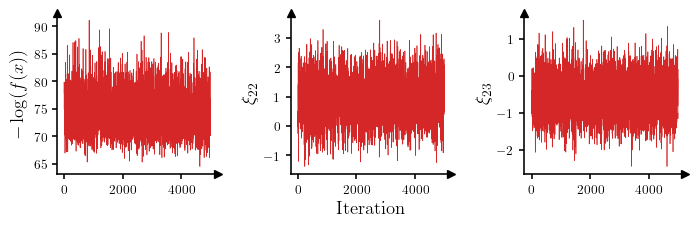

In [13]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Trace plots for the negative log-posterior density (left), and coefficients $\xi_{22}$ (centre) and $\xi_{23}$ (right).
#| label: fig-traces

parameters = torch.hstack((res.potentials[:, None], res.xs[:, 21:23]))
ylabels = [r"$-\log(f(x))$", r"$\xi_{22}$", r"$\xi_{23}$"]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3))

for i, ax in enumerate(axes):
    ax.plot(parameters[:, i], c="tab:red", lw=0.5)
    ax.set_ylabel(ylabels[i])
    ax.set_box_aspect(1)
    add_arrows(ax)

axes[1].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

Finally, @fig-pairs shows a set of prior and posterior samples for three selected coefficients. It is evident that the posterior is significantly different to the prior.

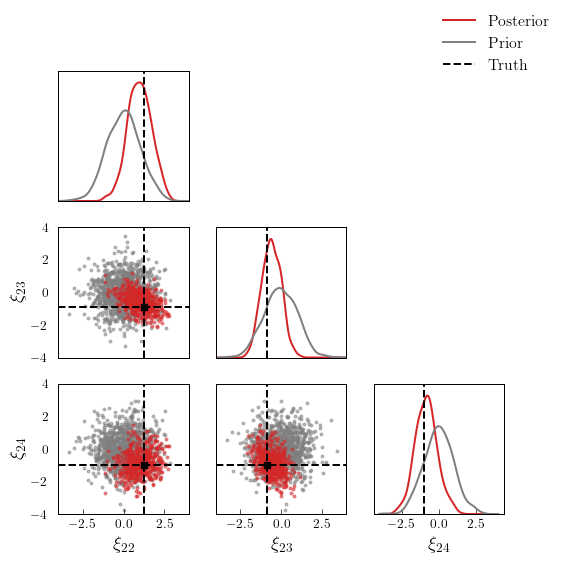

In [14]:
#| code-fold: true
#| fig-align: center
#| fig-cap: A pair plot showing 1000 samples from the prior and posterior of three selected coefficients, as well as the true values.
#| label: fig-pairs

xs_pri = dirt.reference.random(n=1000, d=dirt.dim)
xs_post = res.xs[::10]

labels = [r"$\xi_{"+f"{i}"+r"}$" for i in range(22, 25)]
bounds = torch.tensor([[-4.0, 4.0], [-4.0, 4.0], [-4.0, 4.0]])

pairplot(
    xs_post[:, 21:24], 
    xs_pri[:, 21:24], 
    truth=xi_true[21:24],
    labels=labels, 
    x_label="Posterior",
    y_label="Prior", 
    bounds=bounds
)